# Lab 5: Visualizing PCA

https://archive.ics.uci.edu/dataset/45/heart+disease <br> The heart disease dataset was found on the UC Irvine Machine Learning Repository. The dataset contains data from patients in Cleveland. This dataset contains data used to analyze the factors that can contribute to presence of heart disease in a patient. Features include age, sex, chest pain type, resting blood pressure, serum cholestoral, maximum heart rate, ST depression induced by exercise relative to rest, etc.

### Imports

In [1]:
import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Read CSV

In [3]:
# Read csv file
data = pd.read_csv('processed.cleveland.data')
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Initialize scaler
scaler = StandardScaler()
# Get numeric data only
numeric_data = data.select_dtypes(include=[np.number])
# Standardize features
scaled = scaler.fit_transform(numeric_data)
# Compute covariance matrix
cov_matrix = np.cov(scaled, rowvar=False)
print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 1.00331126 -0.09786527  0.10448379  0.28588945  0.20964216  0.11892273
   0.14936053 -0.3951098   0.09196428  0.20448033  0.16230522  0.22359134]
 [-0.09786527  1.00331126  0.01011728 -0.06466933 -0.20057665  0.0480206
   0.02171903 -0.04882443  0.1466856   0.10251096  0.03765716  0.22521179]
 [ 0.10448379  0.01011728  1.00331126 -0.03619671  0.07255835 -0.04010736
   0.06772876 -0.33552906  0.38533125  0.20294633  0.15255389  0.40842335]
 [ 0.28588945 -0.06466933 -0.03619671  1.00331126  0.13055097  0.17592082
   0.14704569 -0.04550105  0.0649769   0.18979736  0.11777026  0.15827644]
 [ 0.20964216 -0.20057665  0.07255835  0.13055097  1.00331126  0.00987361
   0.1716089  -0.0034432   0.06151339  0.04671817 -0.00407528  0.07114355]
 [ 0.11892273  0.0480206  -0.04010736  0.17592082  0.00987361  1.00331126
   0.06979484 -0.00788015  0.02575013  0.00576625  0.0600925   0.05938207]
 [ 0.14936053  0.02171903  0.06772876  0.14704569  0.1716089   0.06979484
   1.00331126 

### Heatmap

The heatmap visualizes the covariance matrix. The covariance matrix shows the pairwise relationships between standardized features.

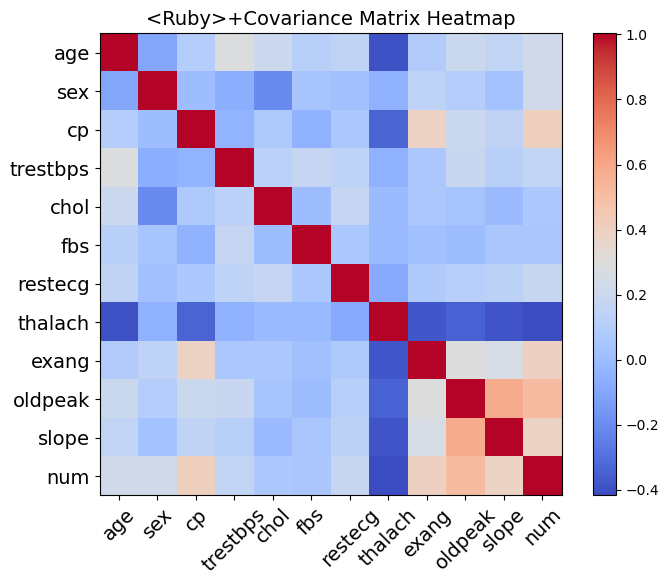

In [7]:
feature_names = numeric_data.columns
# Visualize the covariance matrix as a heatmap
fig = plt.figure(figsize=(8, 6))
plt.imshow(cov_matrix, interpolation='none', cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(feature_names)), feature_names, rotation=45, fontsize=14)
plt.yticks(range(len(feature_names)), feature_names, fontsize=14)
plt.title("<Ruby>+Covariance Matrix Heatmap", fontsize=14)
plt.show()
fig.savefig('RubyCovMatrix.png')

### Compute Eigenvalues and Eigenvectors

Eigenvalues:
[3.09298208 1.53412809 1.20042623 0.35900753 0.42982086 0.44540179
 1.03278455 0.96517023 0.62745786 0.72600874 0.829294   0.79725315]
Eigenvectors:
               PC1       PC2       PC3       PC4       PC5       PC6  \
age       0.262210 -0.422481  0.057487 -0.201745  0.487478 -0.162870   
sex       0.086304  0.404207 -0.451645  0.036410  0.118674  0.328093   
cp        0.297295  0.196346  0.428878  0.072705  0.271972  0.383991   
trestbps  0.160554 -0.461353 -0.310179  0.033199 -0.155674  0.266003   
chol      0.086235 -0.454990  0.387158  0.039673 -0.132507  0.188307   
fbs       0.060639 -0.239631 -0.493861  0.097714 -0.016431 -0.033509   
restecg   0.164437 -0.274430 -0.067447  0.083975  0.027603 -0.025011   
thalach  -0.395641 -0.069010 -0.152704 -0.340654  0.561335 -0.229079   
exang     0.345057  0.207195  0.155453 -0.075373  0.227605 -0.239662   
oldpeak   0.406679  0.050537 -0.171377  0.628613  0.266532 -0.259823   
slope     0.372937  0.051594 -0.187509 -0.5015

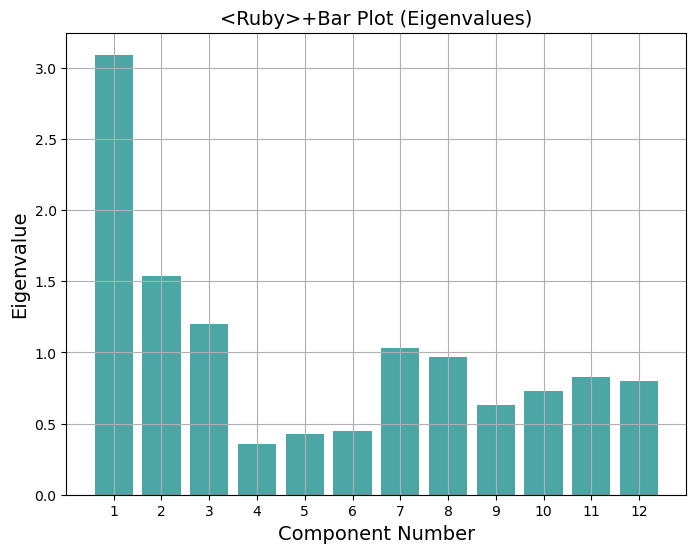

In [9]:
# Compute and print eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:")
print(eigenvalues)
print("Eigenvectors:")
Eigenvectors = pd.DataFrame(
    eigenvectors,
    index=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'num'],
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12']
)
print(Eigenvectors)

# Plot eigenvalues in a bar plot
fig = plt.figure(figsize=(8, 6))
components = np.arange(1, len(eigenvalues) + 1)
plt.bar(components, eigenvalues, color='teal', alpha=0.7)
plt.xlabel('Component Number', fontsize=14)
plt.ylabel('Eigenvalue', fontsize=14)
plt.title('<Ruby>+Bar Plot (Eigenvalues)', fontsize=14)
plt.xticks(components)
plt.grid(True)
plt.show()
fig.savefig('RubyEigenValBar.png')

### 2D PCA Visual

2D PCA Explained Variance Ratio:
[0.25689785 0.12742208]


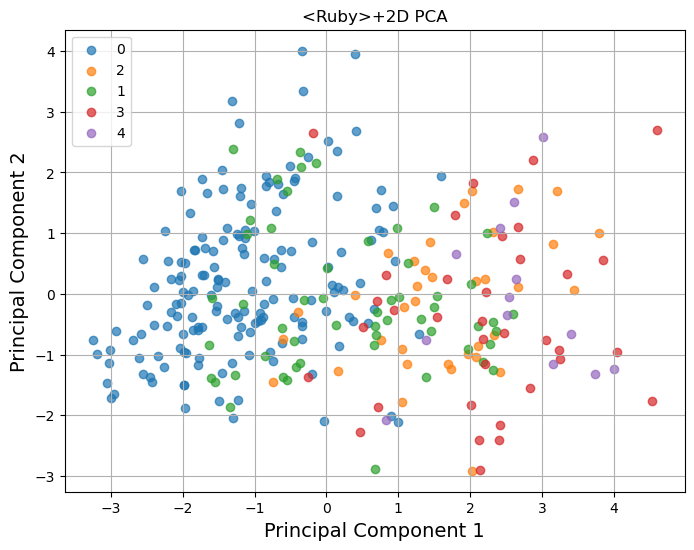

In [11]:
#2D PCA
pca2d = PCA(n_components=2)
X_pca_2d = pca2d.fit_transform(scaled)
pca2d_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca2d_df['num'] = data['num']

# Print explained variance ratio for 2D PCA
print("2D PCA Explained Variance Ratio:")
print(pca2d.explained_variance_ratio_)
fig = plt.figure(figsize=(8, 6))
for num in pca2d_df['num'].unique():
    subset = pca2d_df[pca2d_df['num'] == num]
    plt.scatter(subset['PC1'], subset['PC2'], label=num, alpha=0.7)
    
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('<Ruby>+2D PCA')
plt.legend()
plt.grid(True)
plt.show()
fig.savefig('Ruby2DPCA.png')

### Biplot

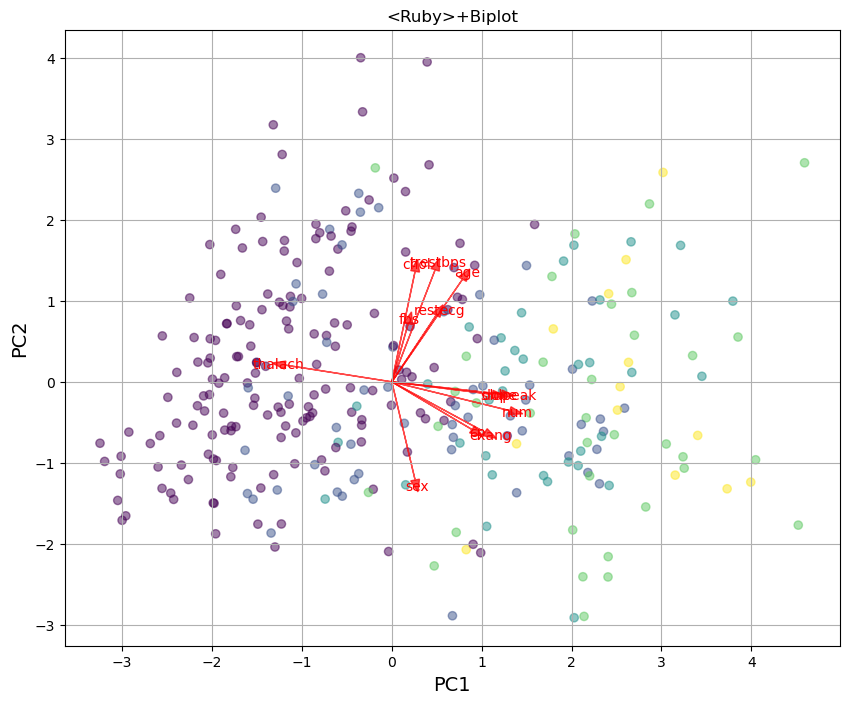

In [17]:
def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    fig = plt.figure(figsize=(10, 8))
    # Scatter plot of the PCA scores
    plt.scatter(xs, ys, c=data['num'], cmap='viridis', alpha=0.5)
    
    for i in range(n):
        # Plot arrows for feature loadings, scaled for visibility
        plt.arrow(0, 0, coeff[i, 0] * 3, coeff[i, 1] * 3, color='r', alpha=0.7, head_width=0.1)
        if labels is None:
            plt.text(coeff[i, 0] * 3.2, coeff[i, 1] * 3.2, "Var"+str(i+1), color='r', ha='center', va='center')
        else:
            plt.text(coeff[i, 0] * 3.2, coeff[i, 1] * 3.2, labels[i], color='r', ha='center', va='center')
    plt.xlabel("PC1", fontsize=14)
    plt.ylabel("PC2", fontsize=14)
    plt.title("<Ruby>+Biplot")
    plt.grid(True)
    plt.show()
    fig.savefig('RubyBiplot.png')

# Calculate the loadings for the 2D PCA 
loadings = pca2d.components_.T

# Create a biplot using the 2D PCA scores and loadings
biplot(X_pca_2d, loadings, labels=feature_names)

### 3D PCA

3D PCA Explained Variance Ratio:
[0.25689785 0.12742208 0.09970537]


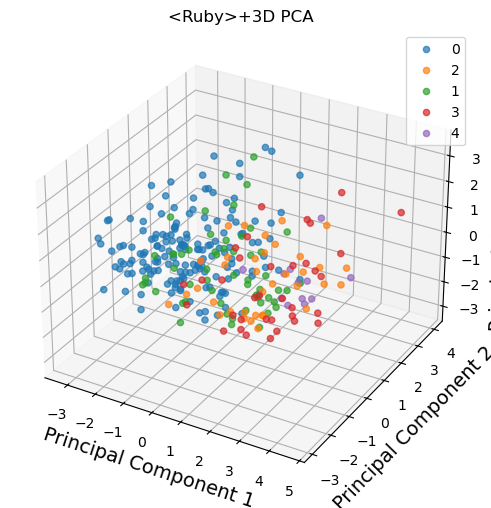

In [15]:
#3D PCA
pca3d = PCA(n_components=3)
columns=['PC1', 'PC2', 'PC3']

X_pca_3d = pca3d.fit_transform(scaled)
pca3d_df = pd.DataFrame(data=X_pca_3d, columns=columns)
pca3d_df['num'] = data['num']

# Print explained variance ratio for 3D PCA
print("3D PCA Explained Variance Ratio:")
print(pca3d.explained_variance_ratio_)
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection = '3d')
for num in pca2d_df['num'].unique():
    subset = pca3d_df[pca3d_df['num'] == num]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], label=num, alpha=0.7)
    
ax.set_xlabel('Principal Component 1', fontsize=14)
ax.set_ylabel('Principal Component 2', fontsize=14)
ax.set_zlabel('Principal Component 3', fontsize=14)
ax.set_title('<Ruby>+3D PCA')
plt.legend()
plt.grid(True)
plt.show()
fig.savefig('Ruby3DPCA.png')